In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [5]:
conn = sqlite3.connect('inventory.db')

df = pd.read_sql_query("SELECT * FROM vendor_sales_summary" , conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5189.0,186752.11,39265.09,9533.99,68601.68,-3624499.49,-1940.807785,0.035766,0.049000
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4771.0,143082.29,30889.70,8765.84,144929.24,-3660958.93,-2558.638760,0.029085,0.037613
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,6095.0,157747.05,28751.89,11198.50,123780.22,-3260556.63,-2066.952523,0.032523,0.046148
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,11562.0,254248.38,27113.67,21244.23,257032.07,-3006949.56,-1182.681896,0.057328,0.077962
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,6655.0,200329.45,31567.54,12227.90,257032.07,-2822876.56,-1409.117112,0.048187,0.066264


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.0000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.5000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.8400,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.9900,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.0000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.0000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.4575,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,1.242153e+02,508.511546,0.00,0.0000,4.000000,61.000000,1.739900e+04
TotalSalesDollars,10692.0,1.624955e+03,6752.709803,0.00,0.0000,89.490000,968.625000,2.542484e+05
TotalSalesPrice,10692.0,8.066506e+02,2226.913336,0.00,0.0000,44.965000,569.497500,3.926509e+04


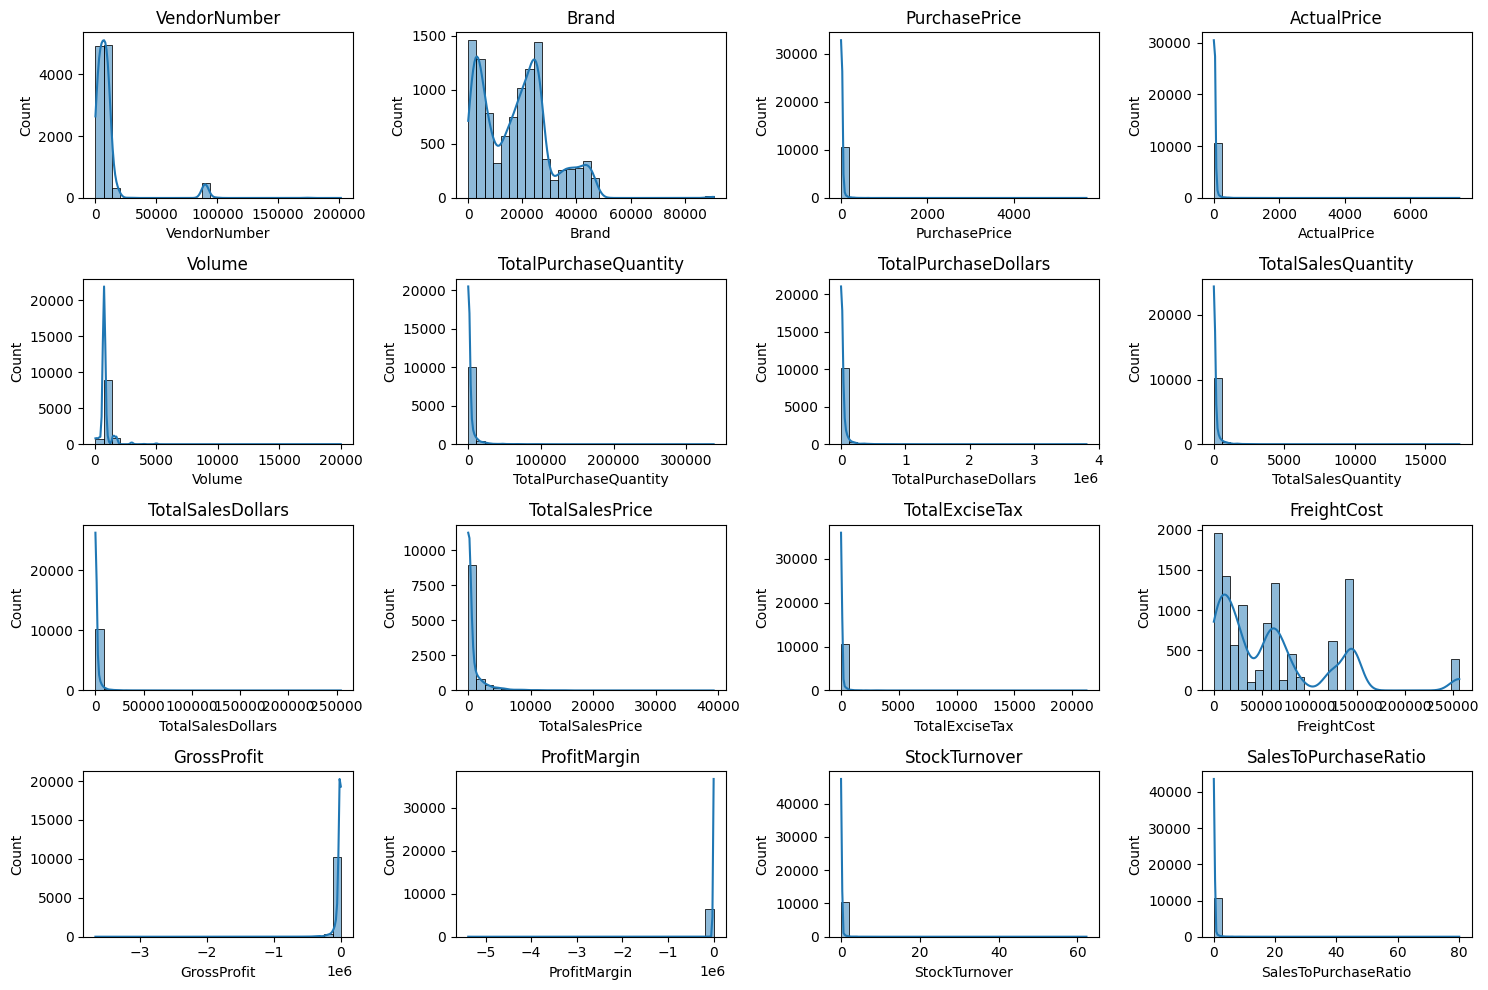

In [10]:
numerical_cols =df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

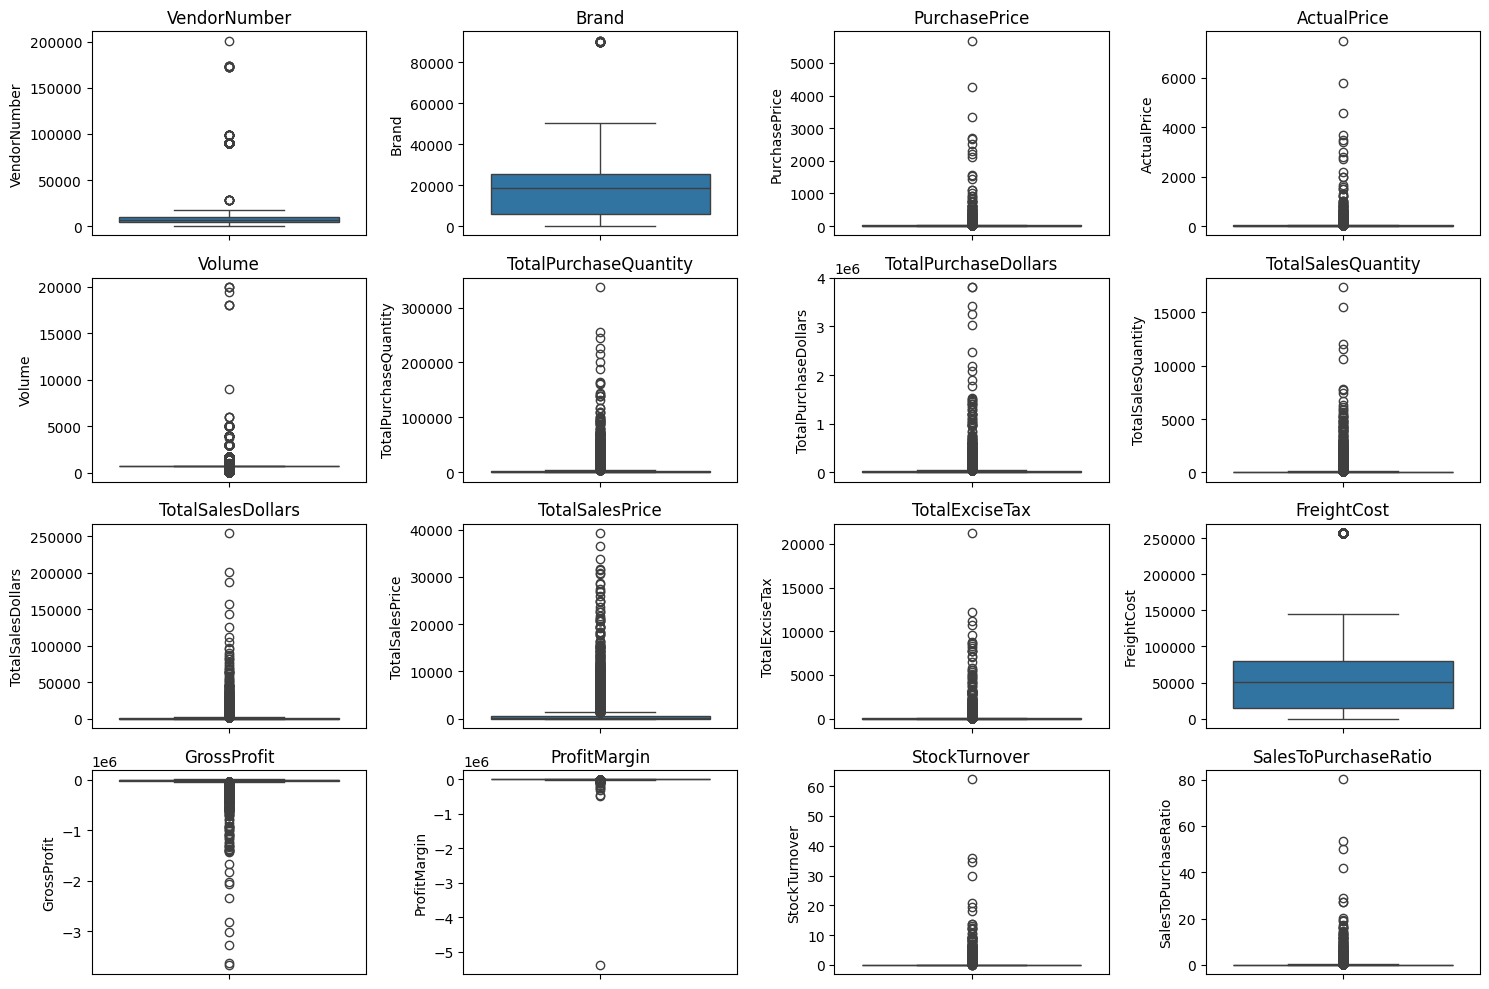

In [12]:
plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [16]:
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0 """ , conn)

In [17]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,9165,ULTRA BEVERAGE COMPANY LLP,24379,Madison's Ranch Cab Svgn,8.78,12.99,750.0,1359,11932.02,1144.0,14860.56,3520.29,128.25,68054.70,2928.54,19.706794,0.841795,1.245435
1,653,STATE WINE & SPIRITS,23256,Robert Hall Cab Svgn,9.39,13.99,750.0,442,4150.38,533.0,7456.67,2839.97,59.51,8014.98,3306.29,44.340034,1.205882,1.796623
2,3960,DIAGEO NORTH AMERICA INC,3757,Ketel One 325 Commemorative,21.63,28.99,1000.0,166,3590.58,157.0,4551.43,1362.53,164.85,257032.07,960.85,21.110948,0.945783,1.267603
3,480,BACARDI USA INC,2679,Dewars Highlander Honey,14.28,22.99,750.0,226,3227.28,233.0,4657.67,3358.32,183.74,89286.27,1430.39,30.710420,1.030973,1.443218
4,9165,ULTRA BEVERAGE COMPANY LLP,24429,Baracchi O'Lillo,8.10,11.99,750.0,375,3037.50,460.0,5515.40,2529.89,51.27,68054.70,2477.90,44.926932,1.226667,1.815770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,9165,ULTRA BEVERAGE COMPANY LLP,21691,Tracia Syrah,5.17,7.49,750.0,1,5.17,4.0,29.96,22.47,0.44,68054.70,24.79,82.743658,4.000000,5.794971
324,3960,DIAGEO NORTH AMERICA INC,7902,Piehole Apple Pie,0.72,0.99,50.0,6,4.32,83.0,82.17,21.78,4.32,257032.07,77.85,94.742607,13.833333,19.020833
325,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,12.0,23.88,1.99,0.63,257032.07,21.04,88.107203,6.000000,8.408451
326,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,2.0,3.98,1.99,0.42,257032.07,2.51,63.065327,2.000000,2.707483


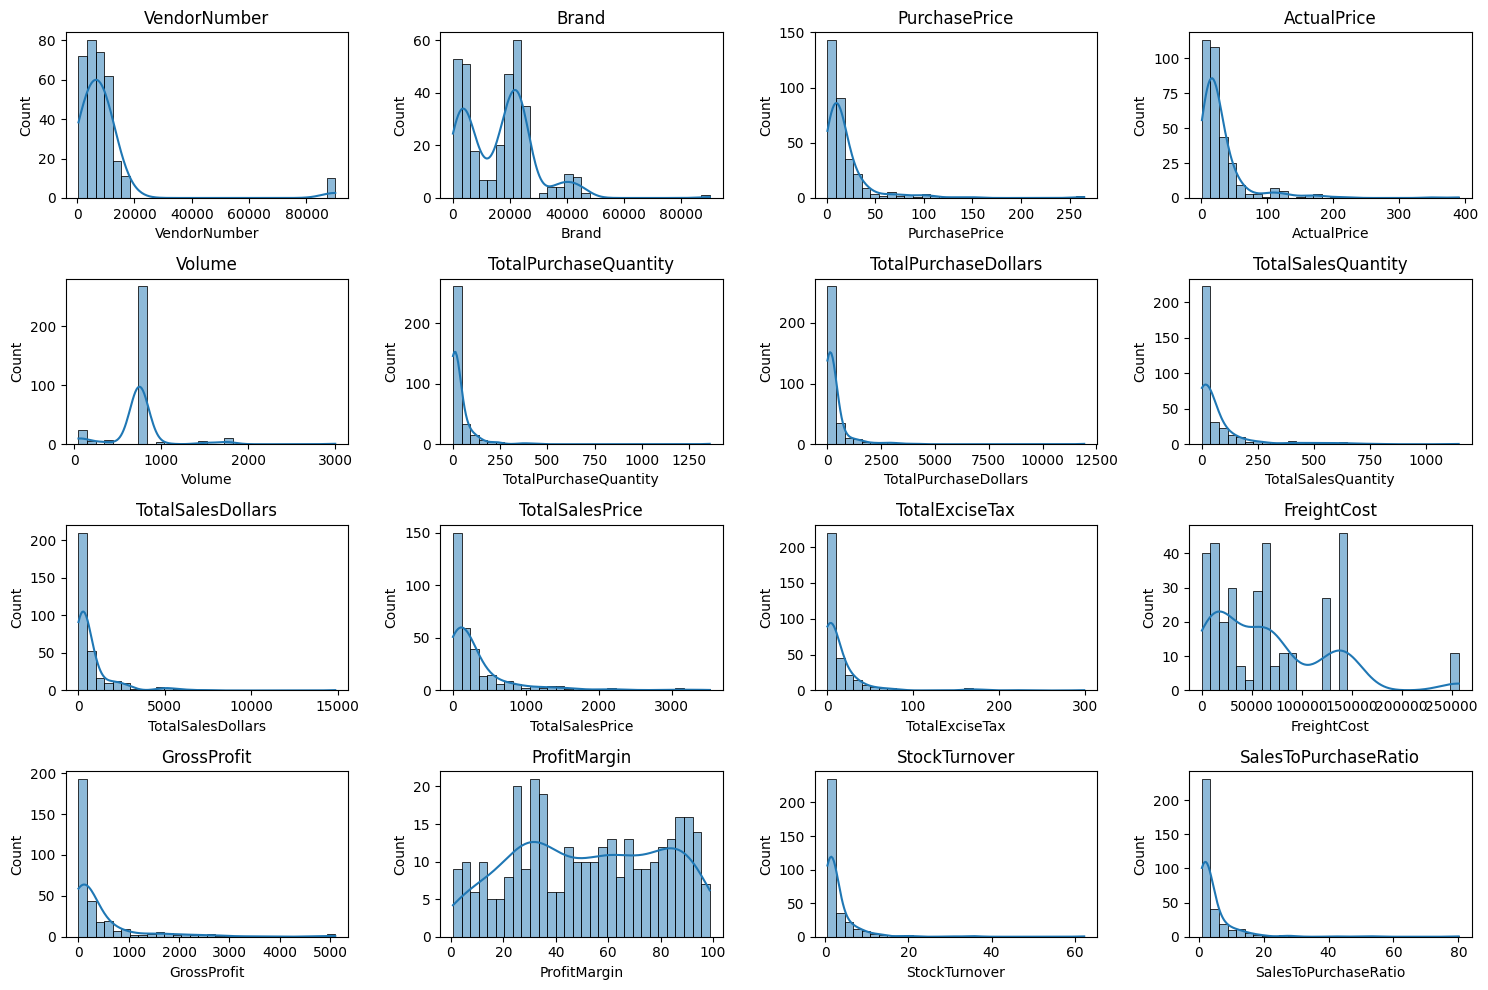

In [18]:
numerical_cols =df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

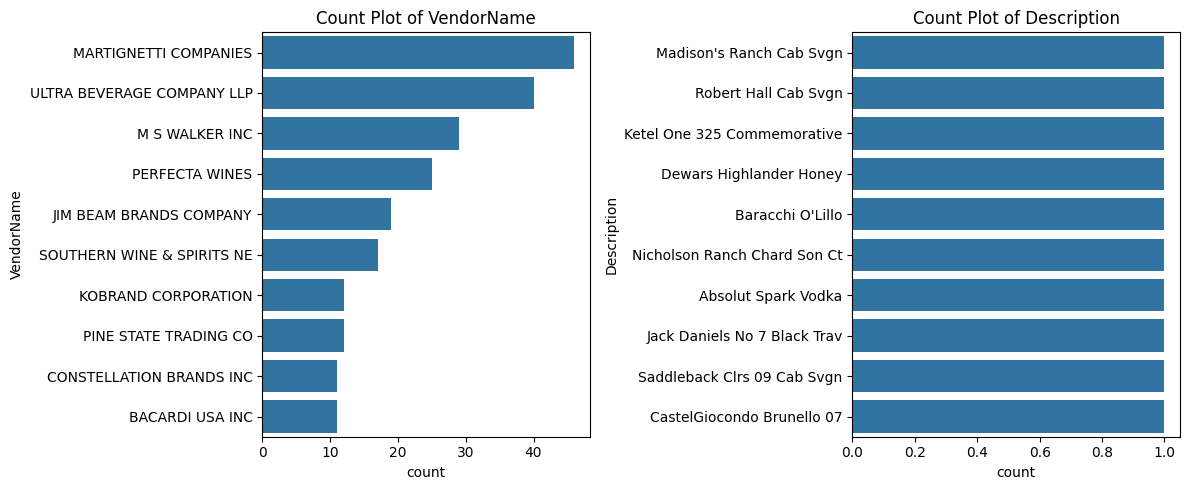

In [19]:
categorical_cols = ["VendorName" , "Description"]


plt.figure(figsize = (12,5))
for i , col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order =df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

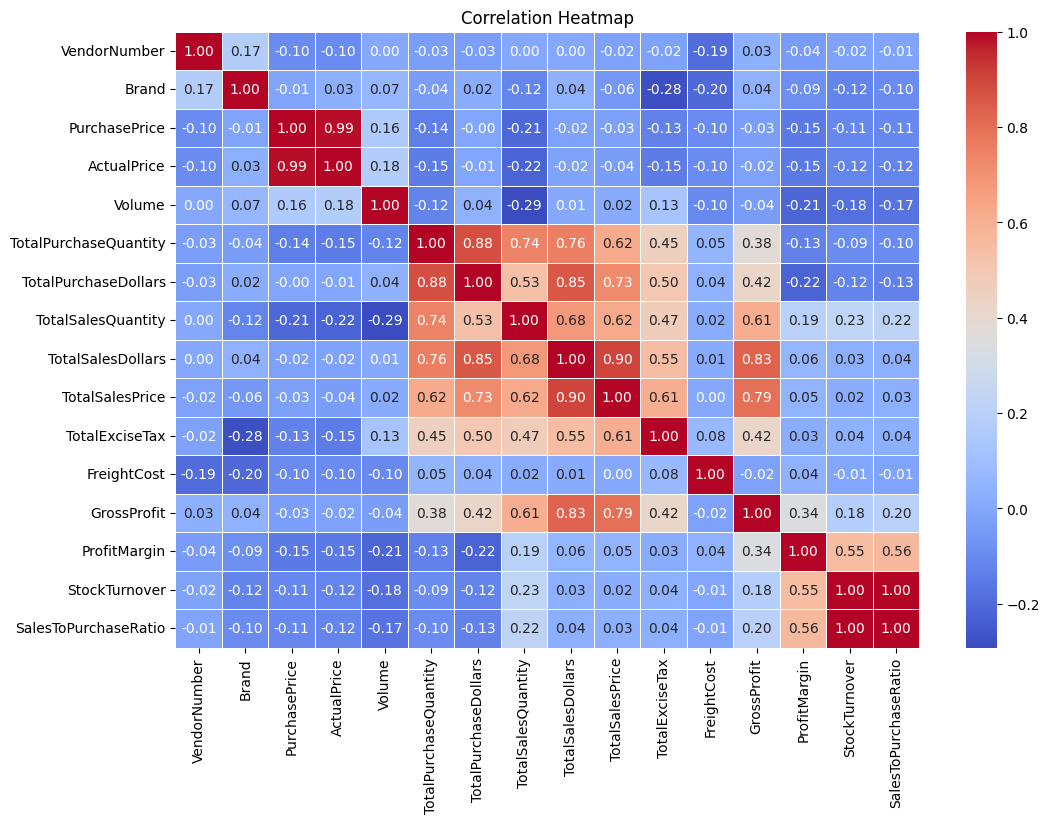

In [20]:
plt.figure(figsize = (12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [25]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [26]:
low_sales_threshold

np.float64(76.9805)

In [27]:
high_margin_threshold

np.float64(86.38610140026877)

In [28]:
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
    ]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
89,Crown Royal Apple,23.88,88.107203
300,Three Olives Grape Vodka,29.70,97.609428
276,St Elder Elderflower Liqueur,53.46,89.375234
0,12 Days of Pearls Gift Set,59.94,88.004671
245,Rhone Roger Sabon 13 CDR Rou,69.95,86.576126


In [35]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000]

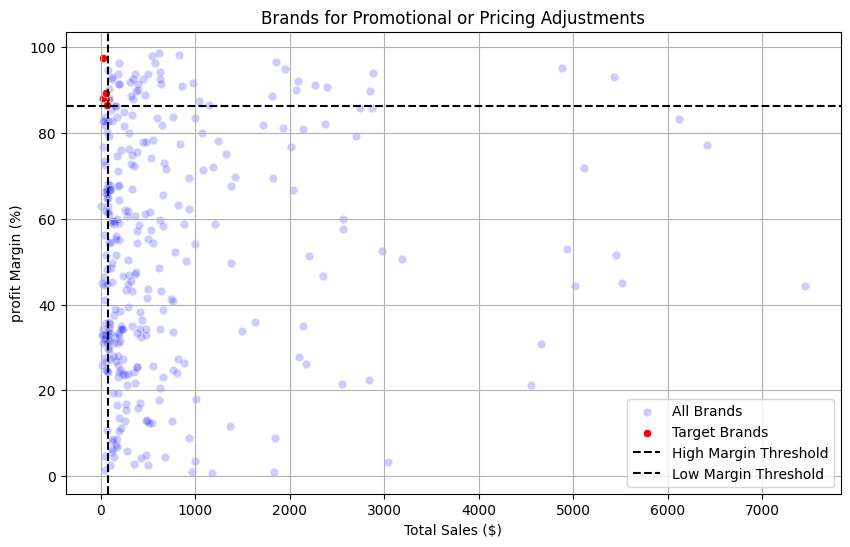

In [36]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = brand_performance, x = 'TotalSalesDollars' , y= 'ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data = target_brands, x = 'TotalSalesDollars' , y= 'ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle = '--', color='black', label = "High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle = '--', color='black', label = "Low Margin Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)

In [37]:
top_vendors =df.groupby("VendorName") ["TotalSalesDollars"].sum().nlargest(10)
top_brands =df.groupby("Description") ["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
ULTRA BEVERAGE COMPANY LLP    51402.66
MARTIGNETTI COMPANIES         37665.00
M S WALKER INC                29615.01
SOUTHERN WINE & SPIRITS NE    14511.63
STATE WINE & SPIRITS          13677.75
BACARDI USA INC               11095.98
BROWN-FORMAN CORP             10531.85
PERFECTA WINES                 8760.13
KOBRAND CORPORATION            7707.52
JIM BEAM BRANDS COMPANY        7641.56
Name: TotalSalesDollars, dtype: float64

In [38]:
top_brands

Description
Madison's Ranch Cab Svgn        14860.56
Robert Hall Cab Svgn             7456.67
Parducci True Grit 11 Cab Sv     6411.99
T-Vine Petite Sirah Napa         6115.92
Baracchi O'Lillo                 5515.40
Jack Daniels No 7 Black Trav     5455.80
Pavilion St Pierre Cdu Rhone     5434.56
Jos Phelps Insignia 2010 Red     5119.60
Absolut Spark Vodka              5019.21
Saddleback Clrs 09 Cab Svgn      4938.70
Name: TotalSalesDollars, dtype: float64

In [41]:
top_brands.apply(lambda x: format_dollars(x))

Description
Madison's Ranch Cab Svgn        14.86K
Robert Hall Cab Svgn             7.46K
Parducci True Grit 11 Cab Sv     6.41K
T-Vine Petite Sirah Napa         6.12K
Baracchi O'Lillo                 5.52K
Jack Daniels No 7 Black Trav     5.46K
Pavilion St Pierre Cdu Rhone     5.43K
Jos Phelps Insignia 2010 Red     5.12K
Absolut Spark Vodka              5.02K
Saddleback Clrs 09 Cab Svgn      4.94K
Name: TotalSalesDollars, dtype: object

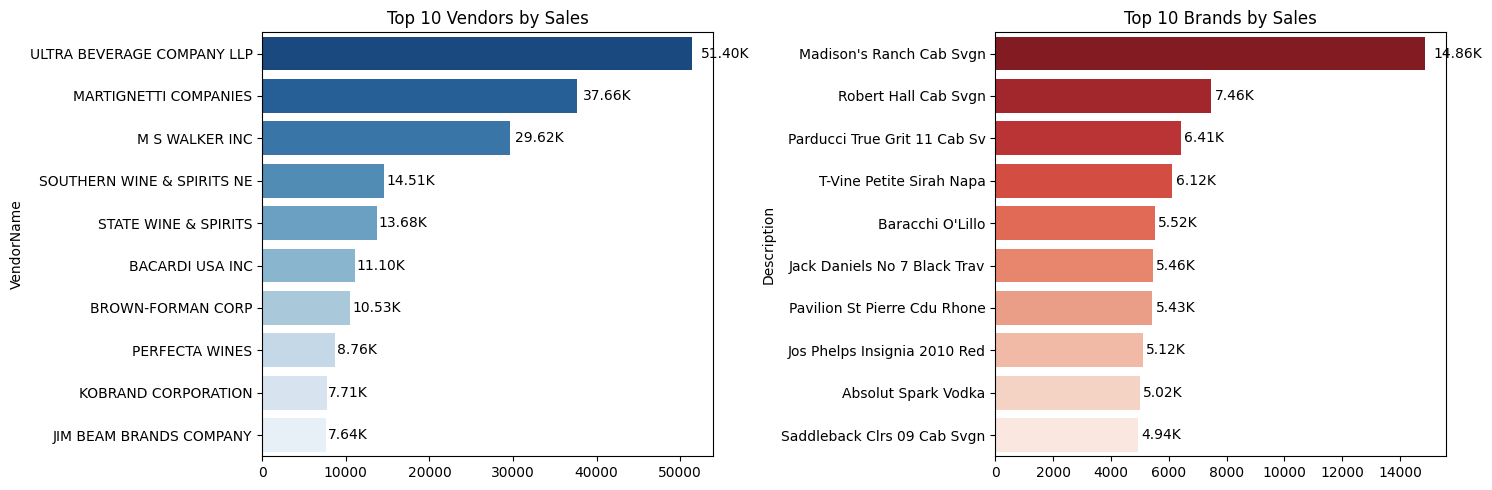

In [42]:
plt.figure(figsize = (15,5))

plt.subplot(1,2,1)
ax1 = sns.barplot(y = top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() *0.02),
             bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color = 'black')
plt.subplot(1,2,2)
ax2=sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

In [54]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(50, 4)

In [61]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()*100

In [62]:
vendor_performance =round(vendor_performance.sort_values('PurchaseContribution%', ascending =False),2)

In [63]:
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
43,ULTRA BEVERAGE COMPANY LLP,25.81K,25.60K,51.40K,22.29
24,MARTIGNETTI COMPANIES,17.61K,20.05K,37.66K,15.21
22,M S WALKER INC,10.67K,18.94K,29.62K,9.22
1,BACARDI USA INC,6.31K,4.78K,11.10K,5.45
38,STATE WINE & SPIRITS,5.26K,8.41K,13.68K,4.55
37,SOUTHERN WINE & SPIRITS NE,4.77K,9.75K,14.51K,4.12
10,DIAGEO NORTH AMERICA INC,4.24K,3.03K,7.26K,3.66
3,BROWN-FORMAN CORP,4.11K,6.42K,10.53K,3.55
30,PERNOD RICARD USA,3.50K,3.62K,7.12K,3.03
29,PERFECTA WINES,3.27K,5.49K,8.76K,2.82


In [64]:
top_vendors['PurchaseContribution%'].sum()

np.float64(73.89999999999999)

In [65]:
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
43,ULTRA BEVERAGE COMPANY LLP,25.81K,25.60K,51.40K,22.29,22.29
24,MARTIGNETTI COMPANIES,17.61K,20.05K,37.66K,15.21,37.50
22,M S WALKER INC,10.67K,18.94K,29.62K,9.22,46.72
1,BACARDI USA INC,6.31K,4.78K,11.10K,5.45,52.17
38,STATE WINE & SPIRITS,5.26K,8.41K,13.68K,4.55,56.72
37,SOUTHERN WINE & SPIRITS NE,4.77K,9.75K,14.51K,4.12,60.84
10,DIAGEO NORTH AMERICA INC,4.24K,3.03K,7.26K,3.66,64.50
3,BROWN-FORMAN CORP,4.11K,6.42K,10.53K,3.55,68.05
30,PERNOD RICARD USA,3.50K,3.62K,7.12K,3.03,71.08
29,PERFECTA WINES,3.27K,5.49K,8.76K,2.82,73.90


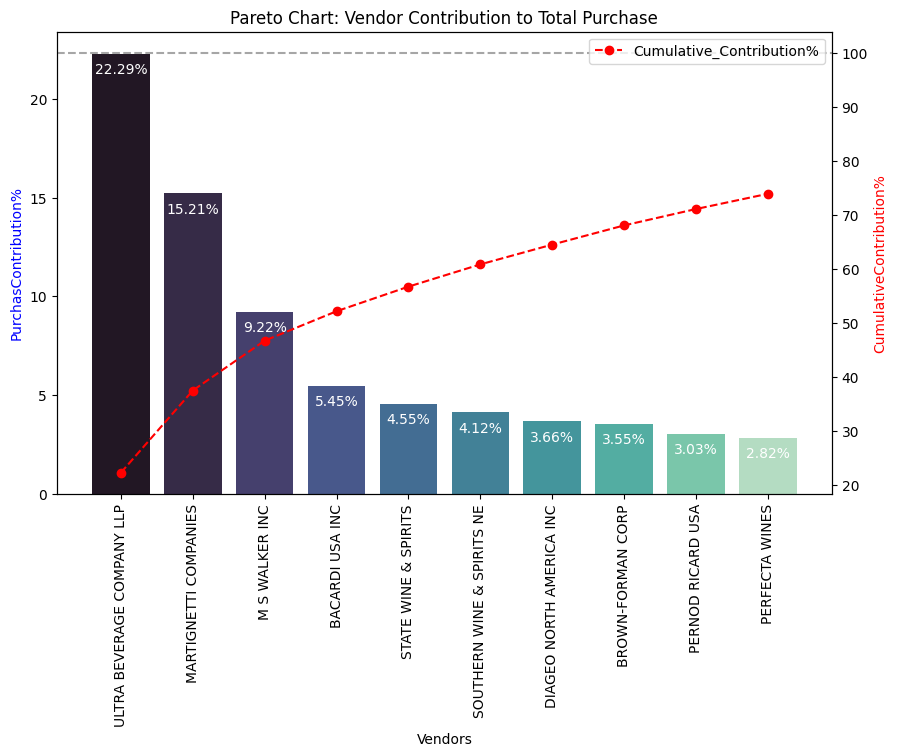

In [66]:
fig, ax1 = plt.subplots(figsize= (10,6))

sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i,value - 1, str(value)+'%', ha = 'center', fontsize=10, color='white')

ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color ='red', marker='o', linestyle='dashed', label='Cumulative_Contribution%')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('PurchasContribution%', color= 'blue')
ax2.set_ylabel('CumulativeContribution%', color = 'red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchase')

ax2.axhline(y=100, color = 'gray', linestyle = 'dashed' , alpha = 0.7)
ax2.legend(loc='upper right')

plt.show()

In [69]:
print(f"Total Purchase Contribution of Top10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total Purchase Contribution of Top10 vendors is 73.9%


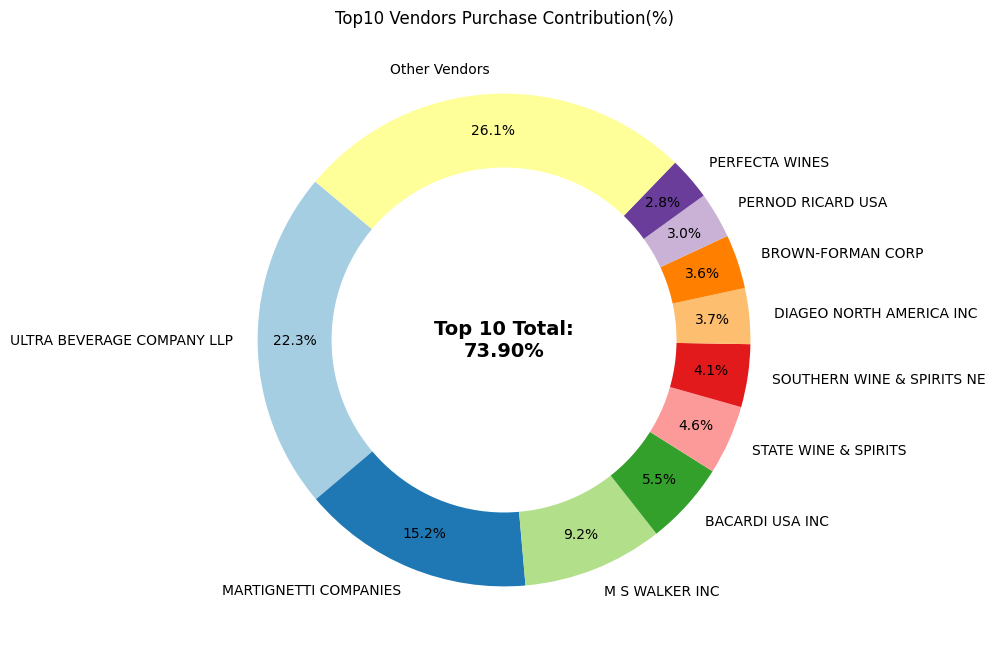

In [71]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions= list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

fig, ax = plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors = plt.cm.Paired.colors)
centre_circle = plt.Circle((0,0),0.70, fc='white')
fig.gca().add_artist(centre_circle)

plt.text(0,0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha ='center', va='center')
plt.title("Top10 Vendors Purchase Contribution(%)")
plt.show()

In [73]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/ df['TotalPurchaseQuantity']

In [74]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small","Medium","Large"])

In [76]:
df[["OrderSize",'TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,1359
1,Large,442
2,Large,166
3,Large,226
4,Large,375
...,...,...
323,Small,1
324,Medium,6
325,Small,2
326,Small,1


In [77]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,32.722521
Medium,16.397475
Large,9.303545


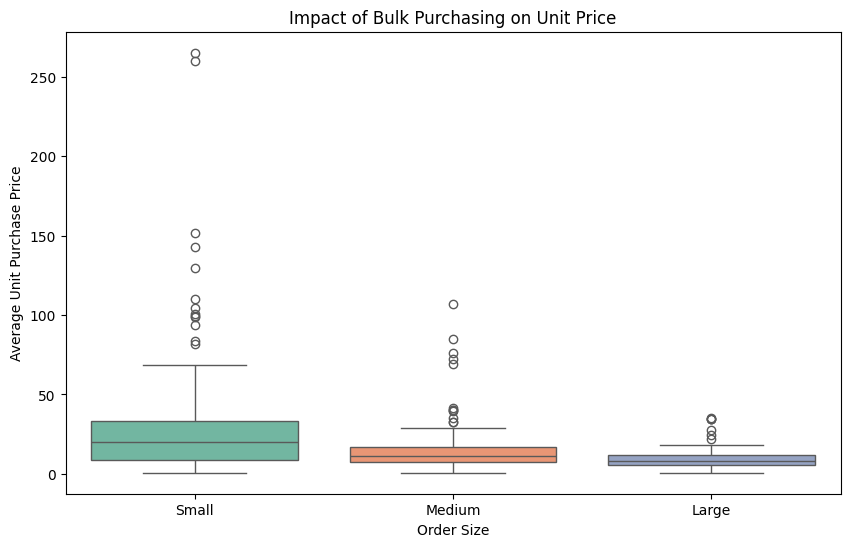

In [78]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="OrderSize", y="UnitPurchasePrice", palette ="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

In [82]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
BANFI PRODUCTS CORP,0.600000
Dunn Wine Brokers,0.680000
FLAG HILL WINERY & VINEYARD,0.692754
E & J GALLO WINERY,0.700000
POVERTY LANE ORCHARDS,0.705882
M S WALKER INC,0.741377
MARTIGNETTI COMPANIES,0.760776
CONSTELLATION BRANDS INC,0.763452
KOBRAND CORPORATION,0.766484


In [83]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"])* df["PurchasePrice"]
print('Total Unsold Capital:',format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: -61464.81


In [85]:
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
2,BANFI PRODUCTS CORP,338.12
13,Dunn Wine Brokers,207.68
4,CAMPARI AMERICA,190.39999999999998
32,POVERTY LANE ORCHARDS,121.5
16,FLAG HILL WINERY & VINEYARD,100.08
41,THE IMPORTED GRAPE LLC,85.12
6,CASTLE BRANDS CORP.,22.120000000000005
17,FREDERICK WILDMAN & SONS,13.42
12,DUGGANS DISTILLED PRODUCTS,0.0
0,ALISA CARR BEVERAGES,0.0


In [87]:
top_theshold = df["TotalSalesDollars"].quantile(0.75)
low_theshold = df["TotalSalesDollars"].quantile(0.25)

In [89]:
top_vendors= df[df["TotalSalesDollars"]>= top_theshold]["ProfitMargin"].dropna()
low_vendors= df[df["TotalSalesDollars"]<= low_theshold]["ProfitMargin"].dropna()

In [90]:
top_vendors


0      19.706794
1      44.340034
2      21.110948
3      30.710420
4      44.926932
         ...    
185    94.837605
199    91.756828
201    90.876876
212    96.530145
297    98.126264
Name: ProfitMargin, Length: 82, dtype: float64

In [91]:
low_vendors

176     5.497622
190     2.602572
206    27.272727
207    31.489111
210    33.333333
         ...    
323    82.743658
324    94.742607
325    88.107203
326    63.065327
327    97.609428
Name: ProfitMargin, Length: 83, dtype: float64

In [95]:
def confidence_interval(data, confidence=0.95):
    mean_val= np.mean(data)
    std_err =np.std(data, ddof=1)/ np.sqrt(len(data))
    t_critical=stats.t.ppf((1+confidence) / 2, df = len(data)-1)
    margin_of_error = t_critical* std_err
    return mean_val,mean_val - margin_of_error,mean_val + margin_of_error

Top Vendors 95% CI: (51.21,63.86), Mean:57.54
Low Vendors 95% CI: (48.36,59.35), Mean:53.85


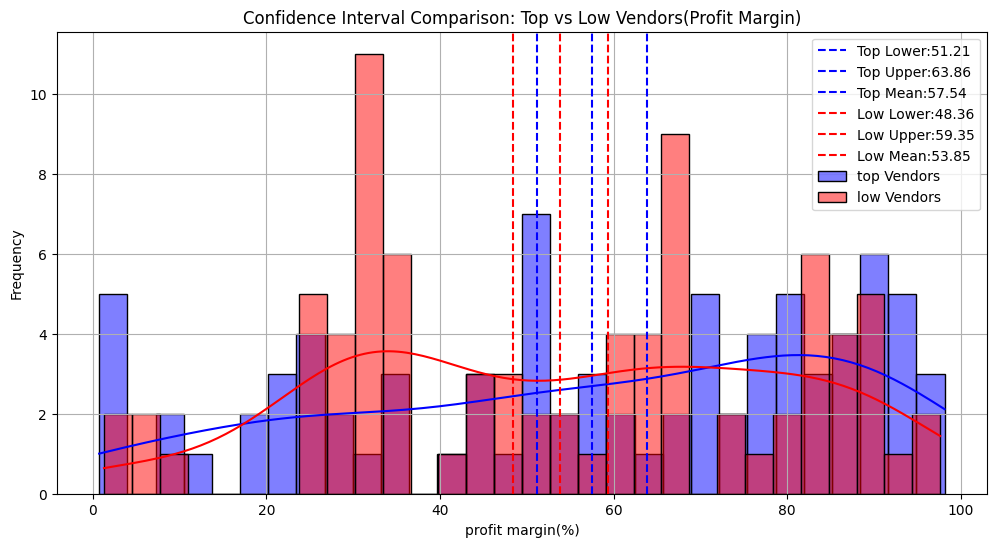

In [99]:
top_mean,top_lower,top_upper = confidence_interval(top_vendors)
low_mean,low_lower,low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f},{top_upper:.2f}), Mean:{top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f},{low_upper:.2f}), Mean:{low_mean:.2f}")

plt.figure(figsize=(12,6))

sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--",label=f"Top Lower:{top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--",label=f"Top Upper:{top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="--",label=f"Top Mean:{top_mean:.2f}")

sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="low Vendors")
plt.axvline(low_lower, color="red", linestyle="--",label=f"Low Lower:{low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--",label=f"Low Upper:{low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="--",label=f"Low Mean:{low_mean:.2f}")

plt.title("Confidence Interval Comparison: Top vs Low Vendors(Profit Margin)")
plt.xlabel("profit margin(%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [100]:
top_theshold = df["TotalSalesDollars"].quantile(0.75)
low_theshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors= df[df["TotalSalesDollars"]>= top_theshold]["ProfitMargin"].dropna()
low_vendors= df[df["TotalSalesDollars"]<= low_theshold]["ProfitMargin"].dropna()

t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}, P-Value:{p_value:.4f}")
if p_value <0.05:
    print("Reject H: There is a significant difference in profile margins between top and low performing vendors.")
else:
    print("Fail to Reject H: No significant difference in profile margins.")

T-Statistic: 0.8754, P-Value:0.3827
Fail to Reject H: No significant difference in profile margins.
